Education Graphs using Matplotlib

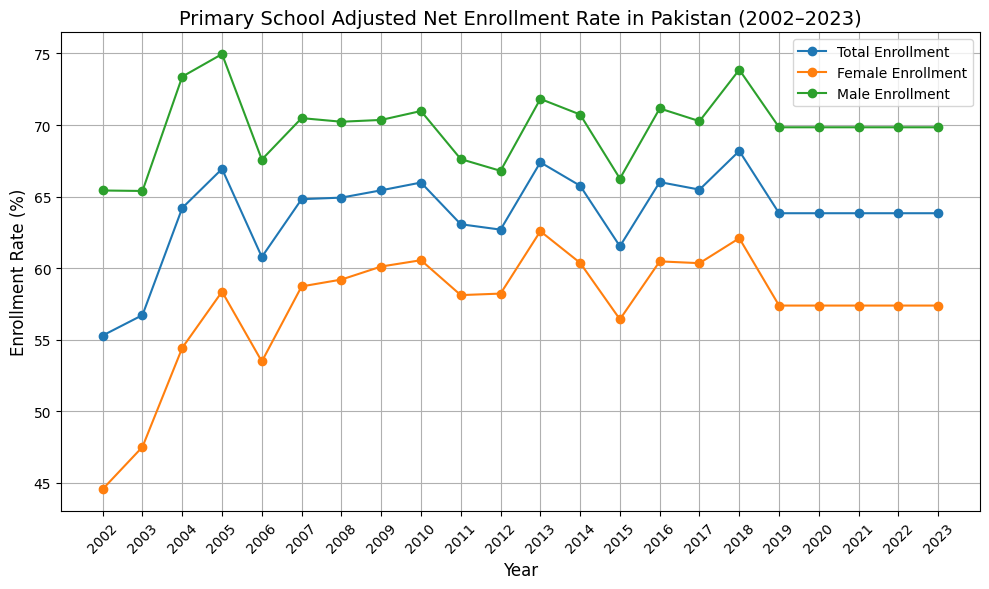

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
csv_file = "education.csv"  # Update path if necessary
df = pd.read_csv(csv_file)

# Filter for the desired indicators
indicators = ['SE.PRM.TENR', 'SE.PRM.TENR.FE', 'SE.PRM.TENR.MA']
df_filtered = df[df['Series Code'].isin(indicators)]

# Select columns for years 2002–2023
year_columns = [f"{year} [YR{year}]" for year in range(2002, 2024)]
data_columns = ['Series Name'] + year_columns
df_filtered = df_filtered[data_columns]

# Clean and prepare data
# Convert year columns to numeric, handling any non-numeric values
for col in year_columns:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Transpose data for plotting
df_transposed = df_filtered.set_index('Series Name')[year_columns].T
df_transposed.index = [int(col.split()[0]) for col in df_transposed.index]  # Extract year as integer

# Rename columns for clarity
df_transposed.columns = [
    'Total Enrollment',
    'Female Enrollment',
    'Male Enrollment'
]

# Create the time series line chart
plt.figure(figsize=(10, 6))
for column in df_transposed.columns:
    plt.plot(df_transposed.index, df_transposed[column], marker='o', label=column)

# Customize the plot
plt.title('Primary School Adjusted Net Enrollment Rate in Pakistan (2002–2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Enrollment Rate (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(df_transposed.index, rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

Education Graphs using Plotly

In [ ]:
import pandas as pd
import plotly.express as px

# Load the CSV file
csv_file = "education.csv"  # Update path if necessary
df = pd.read_csv(csv_file)

# Filter for the desired indicators
indicators = ['SE.PRM.TENR', 'SE.PRM.TENR.FE', 'SE.PRM.TENR.MA']
df_filtered = df[df['Series Code'].isin(indicators)]

# Select columns for years 2002–2023
year_columns = [f"{year} [YR{year}]" for year in range(2002, 2024)]
data_columns = ['Series Name'] + year_columns
df_filtered = df_filtered[data_columns]

# Clean and prepare data
# Convert year columns to numeric, handling any non-numeric values
for col in year_columns:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Melt the DataFrame to a long format for Plotly Express
df_melted = df_filtered.melt(id_vars='Series Name', value_vars=year_columns, var_name='Year', value_name='Enrollment Rate (%)')

# Extract year as integer from the Year column
df_melted['Year'] = df_melted['Year'].apply(lambda x: int(x.split()[0]))

# Rename Series Name values for clarity
series_names_map = {
    'SE.PRM.TENR': 'Total Enrollment',
    'SE.PRM.TENR.FE': 'Female Enrollment',
    'SE.PRM.TENR.MA': 'Male Enrollment'
}
df_melted['Series Name'] = df_melted['Series Name'].map(series_names_map)

# Create the interactive time series line chart
fig = px.line(
    df_melted,
    x='Year',
    y='Enrollment Rate (%)',
    color='Series Name',
    title='Primary School Adjusted Net Enrollment Rate in Pakistan (2002–2023)'
)

# Customize the layout (optional)
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Enrollment Rate (%)',
    legend_title='Enrollment Type',
    hovermode='x unified' # Adds tooltip when hovering over the x-axis
)

# Show the plot
fig.show()

Finance Graphs using Matplotlib

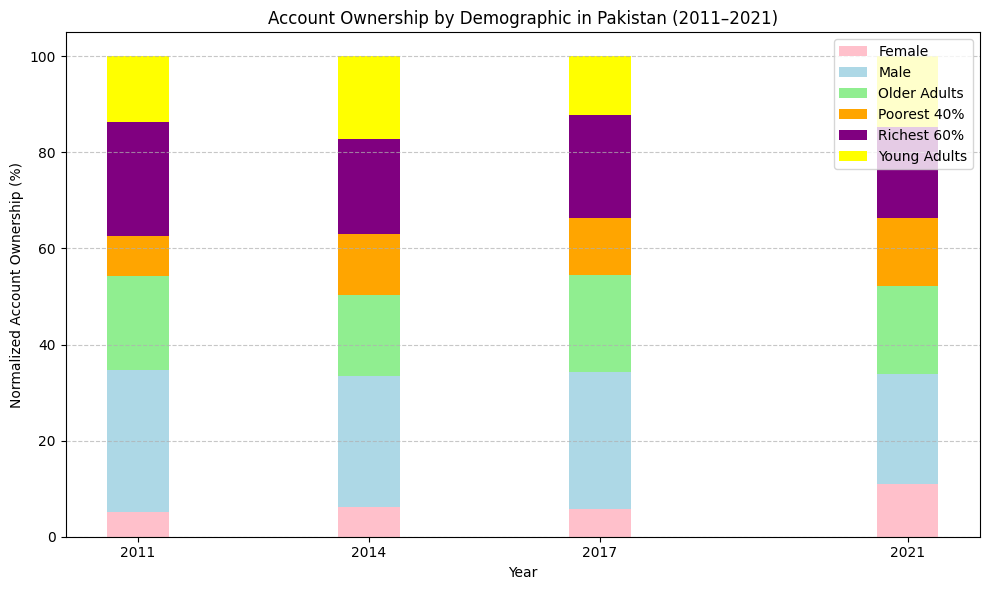

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Save the provided financial data to a temporary CSV file
data = """
,Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],1966 [YR1966],1967 [YR1967],1968 [YR1968],1969 [YR1969],1970 [YR1970],1971 [YR1971],1972 [YR1972],1973 [YR1973],1974 [YR1974],1975 [YR1975],1976 [YR1976],1977 [YR1977],1978 [YR1978],1979 [YR1979],1980 [YR1980],1981 [YR1981],1982 [YR1982],1983 [YR1983],1984 [YR1984],1985 [YR1985],1986 [YR1986],1987 [YR1987],1988 [YR1988],1989 [YR1989],1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],1996 [YR1996],1997 [YR1997],1998 [YR1998],1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Pakistan,PAK,Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),FX.OWN.TOTL.ZS,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,16.405,10.31,16.405,16.405,13.04,16.405,16.405,21.29,16.405,16.405,16.405,20.98,16.405,16.405
1,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)",FX.OWN.TOTL.FE.ZS,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,7.075,2.95,7.075,7.075,4.84,7.075,7.075,7.03,7.075,7.075,7.075,13.48,7.075,7.075
2,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",FX.OWN.TOTL.MA.ZS,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,25.259999999999998,17.28,25.259999999999998,25.259999999999998,20.97,25.259999999999998,25.259999999999998,34.61,25.259999999999998,25.259999999999998,25.259999999999998,28.18,25.259999999999998,25.259999999999998
3,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, older adults (% of population ages 25+)",FX.OWN.TOTL.OL.ZS,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,17.8825,11.45,17.8825,17.8825,12.96,17.8825,17.8825,24.58,17.8825,17.8825,17.8825,22.54,17.8825,17.8825
4,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, poorest 40% (% of population ages 15+)",FX.OWN.TOTL.40.ZS,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,11.5975,4.81,11.5975,11.5975,9.75,11.5975,11.5975,14.22,11.5975,11.5975,11.5975,17.61,11.5975,11.5975
5,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, primary education or less (% of population ages 15+)",FX.OWN.TOTL.PL.ZS,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,11.252500000000001,3.75,11.252500000000001,11.252500000000001,10.03,11.252500000000001,11.252500000000001,15.92,11.252500000000001,11.252500000000001,11.252500000000001,15.31,11.252500000000001,11.252500000000001
6,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, richest 60% (% of population ages 15+)",FX.OWN.TOTL.60.ZS,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,19.59,13.94,19.59,19.59,15.21,19.59,19.59,26.0,19.59,19.59,19.59,23.21,19.59,19.59
7,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, secondary education or more (% of population ages 15+)",FX.OWN.TOTL.SO.ZS,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,29.744999999999997,24.46,29.744999999999997,29.744999999999997,25.19,29.744999999999997,29.744999999999997,34.03,29.744999999999997,29.744999999999997,29.744999999999997,35.3,29.744999999999997,29.744999999999997
8,Pakistan,PAK,"Account ownership at a financial institution or with a mobile-money-service provider, young adults (% of population ages 15-24)",FX.OWN.TOTL.YG.ZS,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,13.535,7.95,13.535,13.535,13.2,13.535,13.535,14.89,13.535,13.535,13.535,18.1,13.535,13.535
"""

with open('finance.csv', 'w') as f:
    f.write(data)

# Read CSV using read_csv
df = pd.read_csv('finance.csv')

# Filter for the six selected indicators
indicators = [
    'FX.OWN.TOTL.FE.ZS',  # Female
    'FX.OWN.TOTL.MA.ZS',  # Male
    'FX.OWN.TOTL.OL.ZS',  # Older adults
    'FX.OWN.TOTL.40.ZS',  # Poorest 40%
    'FX.OWN.TOTL.60.ZS',  # Richest 60%
    'FX.OWN.TOTL.YG.ZS'   # Young adults
]
df_filtered = df[df['Series Code'].isin(indicators)]

# Select years with actual data
years = ['2011 [YR2011]', '2014 [YR2014]', '2017 [YR2017]', '2021 [YR2021]']
df_filtered = df_filtered[['Series Name'] + years]

# Convert to numeric
for col in years:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Pivot data
df_pivot = df_filtered.set_index('Series Name')[years].T
df_pivot.index = [int(col.split()[0]) for col in df_pivot.index]
df_pivot.columns = [
    'Female', 'Male', 'Older Adults', 'Poorest 40%', 'Richest 60%', 'Young Adults'
]

# Normalize values to sum to 100 for stacking
df_normalized = df_pivot.copy()
for year in df_pivot.index:
    total = df_pivot.loc[year].sum()
    if total > 0:
        df_normalized.loc[year] = (df_pivot.loc[year] / total) * 100
    else:
        df_normalized.loc[year] = 0

# Plot stacked bar
plt.figure(figsize=(10, 6))
bottom = None
colors = ['pink', 'lightblue', 'lightgreen', 'orange', 'purple', 'yellow']
for i, column in enumerate(df_normalized.columns):
    plt.bar(df_normalized.index, df_normalized[column], bottom=bottom, label=column, color=colors[i])
    if bottom is None:
        bottom = df_normalized[column]
    else:
        bottom += df_normalized[column]

# Customize plot
plt.title('Account Ownership by Demographic in Pakistan (2011–2021)')
plt.xlabel('Year')
plt.ylabel('Normalized Account Ownership (%)')
plt.legend()
plt.xticks(df_normalized.index)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and show
plt.savefig('account_ownership_stacked_bar.png')
plt.show()

Finance Graphs using Plotly

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Read CSV
df = pd.read_csv('finance.csv')

# Filter for the six selected indicators
indicators = [
    'FX.OWN.TOTL.FE.ZS',  # Female
    'FX.OWN.TOTL.MA.ZS',  # Male
    'FX.OWN.TOTL.OL.ZS',  # Older adults
    'FX.OWN.TOTL.40.ZS',  # Poorest 40%
    'FX.OWN.TOTL.60.ZS',  # Richest 60%
    'FX.OWN.TOTL.YG.ZS'   # Young adults
]
df_filtered = df[df['Series Code'].isin(indicators)]

# Select years with actual data
years = ['2011 [YR2011]', '2014 [YR2014]', '2017 [YR2017]', '2021 [YR2021]']
df_filtered = df_filtered[['Series Name'] + years]

# Convert to numeric
for col in years:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Pivot data
df_pivot = df_filtered.set_index('Series Name')[years].T
df_pivot.index = [int(col.split()[0]) for col in df_pivot.index]
df_pivot.columns = [
    'Female', 'Male', 'Older Adults', 'Poorest 40%', 'Richest 60%', 'Young Adults'
]

# Normalize values to sum to 100 for stacking
df_normalized = df_pivot.copy()
for year in df_pivot.index:
    total = df_pivot.loc[year].sum()
    if total > 0:
        df_normalized.loc[year] = (df_pivot.loc[year] / total) * 100
    else:
        df_normalized.loc[year] = 0

# Create Plotly figure
fig = go.Figure()

# Colors for each demographic
colors = ['pink', 'lightblue', 'lightgreen', 'orange', 'purple', 'yellow']

# Add stacked bars
for i, column in enumerate(df_normalized.columns):
    fig.add_trace(go.Bar(
        x=df_normalized.index,
        y=df_normalized[column],
        name=column,
        marker_color=colors[i]
    ))

# Update layout for stacked bars and styling
fig.update_layout(
    title='Account Ownership by Demographic in Pakistan (2011–2021)',
    xaxis_title='Year',
    yaxis_title='Normalized Account Ownership (%)',
    barmode='stack',
    xaxis=dict(tickmode='array', tickvals=df_normalized.index),
    yaxis=dict(gridcolor='rgba(0,0,0,0.1)'),
    showlegend=True,
    template='plotly_white',
    width=800,
    height=600
)

# Display the plot
fig.show()

Health Grpahs using Plotly


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Read the CSV file
# Adjust the path if needed
df = pd.read_csv('health.csv')

# Define the indicators to visualize
indicators = [
    'Adolescent fertility rate (births per 1,000 women ages 15-19)',
    'Birth rate, crude (per 1,000 people)',
    'Births attended by skilled health staff (% of total)',
    'Current health expenditure (% of GDP)',
    'Tuberculosis treatment success rate (% of new cases)'
]

# Filter data for selected indicators
df_filtered = df[df['Series Name'].isin(indicators)]

# Select columns for years 2000–2023
year_columns = [f'{year} [YR{year}]' for year in range(2000, 2024)]
data_dict = {'year': list(range(2000, 2024))}

# Process data for each indicator
for indicator in indicators:
    indicator_data = df_filtered[df_filtered['Series Name'] == indicator][year_columns].iloc[0]
    # Convert to numeric, handling non-numeric values
    values = pd.to_numeric(indicator_data, errors='coerce').values
    data_dict[indicator] = values

# Create a DataFrame for plotting
plot_df = pd.DataFrame(data_dict)

# Create subplots: 2 rows, 2 columns
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Fertility and Birth Rates',
        'Births Attended by Skilled Health Staff',
        'Current Health Expenditure (% of GDP)',
        'Tuberculosis Treatment Success Rate'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Plot 1: Line plot for fertility and birth rates
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Adolescent fertility rate (births per 1,000 women ages 15-19)'],
        name='Adolescent Fertility Rate',
        line=dict(color='blue', width=2),
        mode='lines+markers'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Birth rate, crude (per 1,000 people)'],
        name='Crude Birth Rate',
        line=dict(color='orange', width=2),
        mode='lines+markers'
    ),
    row=1, col=1
)

# Plot 2: Area plot for births attended by skilled health staff
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Births attended by skilled health staff (% of total)'],
        name='Skilled Birth Attendance',
        fill='tozeroy',
        line=dict(color='green', width=2),
        mode='lines+markers'
    ),
    row=1, col=2
)

# Plot 3: Bar plot for health expenditure
fig.add_trace(
    go.Bar(
        x=plot_df['year'],
        y=plot_df['Current health expenditure (% of GDP)'],
        name='Health Expenditure',
        marker_color='purple'
    ),
    row=2, col=1
)

# Plot 4: Line plot for TB treatment success rate
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Tuberculosis treatment success rate (% of new cases)'],
        name='TB Treatment Success',
        line=dict(color='gold', width=2),
        mode='lines+markers'
    ),
    row=2, col=2
)

# Update layout for better styling
fig.update_layout(
    title=dict(
        text='Pakistan Health Indicators (2000–2023)',
        x=0.5,
        xanchor='center',
        font=dict(size=24, color='black')
    ),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=-0.3, xanchor='center', x=0.5),
    height=800,
    width=1000,
    template='plotly_white',
    margin=dict(l=50, r=50, t=100, b=100)
)

# Update axes labels
fig.update_xaxes(title_text='Year', row=1, col=1)
fig.update_yaxes(title_text='Rate (per 1,000)', row=1, col=1)
fig.update_xaxes(title_text='Year', row=1, col=2)
fig.update_yaxes(title_text='Percentage (%)', row=1, col=2)
fig.update_xaxes(title_text='Year', row=2, col=1)
fig.update_yaxes(title_text='% of GDP', row=2, col=1)
fig.update_xaxes(title_text='Year', row=2, col=2)
fig.update_yaxes(title_text='Success Rate (%)', row=2, col=2)

# Display the plot
fig.show()

Poverty Grpahs using Plotly

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Load the data
file_path = 'poverty.csv'
data = pd.read_csv(file_path)

# Drop the unnecessary 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])

# Clean year columns
year_columns = [col for col in data.columns if '[YR' in col]
years = [int(col.split(' ')[0]) for col in year_columns]

# Select a few features to plot (first 5)
selected_features = data['Series Name'].iloc[0:5]
feature_data = data.iloc[0:5, data.columns.get_loc(year_columns[0]):data.columns.get_loc(year_columns[-1])+1]

# Create Plotly figure
fig = go.Figure()

# Colors for different features
colors = ['blue', 'orange', 'green', 'red', 'purple']

# Add a line for each feature
for idx, feature in enumerate(selected_features):
    values = feature_data.iloc[idx].astype(float)
    fig.add_trace(
        go.Scatter(
            x=years,
            y=values,
            mode='lines+markers',
            name=feature,
            line=dict(color=colors[idx], width=2)
        )
    )

# Update layout for better styling
fig.update_layout(
    title=dict(
        text='Multiple Features Over Years',
        x=0.5,
        xanchor='center',
        font=dict(size=24, color='black')
    ),
    xaxis_title='Year',
    yaxis_title='Value',
    showlegend=True,
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01),
    template='plotly_white',
    width=1000,
    height=600,
    xaxis=dict(gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(gridcolor='rgba(0,0,0,0.1)')
)

# Display the plot
fig.show()

Social Protection Nad labor using plotly


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Read the CSV file
# Adjust the path if needed
df = pd.read_csv('social_protection_labor.csv')

# Define the indicators to visualize
indicators = [
    'Adequacy of social safety net programs (% of total welfare of beneficiary households)',
    'Children in employment, total (% of children ages 7-14)',
    'Unemployment, total (% of total labor force) (national estimate)',
    'Vulnerable employment, total (% of total employment) (modeled ILO estimate)'
]

# Filter data for selected indicators
df_filtered = df[df['Series Name'].isin(indicators)]

# Select columns for years 2000–2023
year_columns = [f'{year} [YR{year}]' for year in range(2000, 2024)]
data_dict = {'year': list(range(2000, 2024))}

# Process data for each indicator
for indicator in indicators:
    indicator_data = df_filtered[df_filtered['Series Name'] == indicator][year_columns].iloc[0]
    # Convert to numeric, handling non-numeric values
    values = pd.to_numeric(indicator_data, errors='coerce').values
    data_dict[indicator] = values

# Create a DataFrame for plotting
plot_df = pd.DataFrame(data_dict)

# Create subplots: 2 rows, 2 columns
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Adequacy of Social Safety Nets',
        'Children in Employment (Ages 7-14)',
        'Total Unemployment (National Estimate)',
        'Vulnerable Employment'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Plot 1: Line plot for adequacy of social safety net programs
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Adequacy of social safety net programs (% of total welfare of beneficiary households)'],
        name='Social Safety Net Adequacy',
        line=dict(color='blue', width=2),
        mode='lines+markers'
    ),
    row=1, col=1
)

# Plot 2: Area plot for children in employment
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Children in employment, total (% of children ages 7-14)'],
        name='Child Employment',
        fill='tozeroy',
        line=dict(color='green', width=2),
        mode='lines+markers'
    ),
    row=1, col=2
)

# Plot 3: Bar plot for total unemployment
fig.add_trace(
    go.Bar(
        x=plot_df['year'],
        y=plot_df['Unemployment, total (% of total labor force) (national estimate)'],
        name='Total Unemployment',
        marker_color='purple'
    ),
    row=2, col=1
)

# Plot 4: Line plot for vulnerable employment
fig.add_trace(
    go.Scatter(
        x=plot_df['year'],
        y=plot_df['Vulnerable employment, total (% of total employment) (modeled ILO estimate)'],
        name='Vulnerable Employment',
        line=dict(color='gold', width=2),
        mode='lines+markers'
    ),
    row=2, col=2
)

# Update layout for better styling
fig.update_layout(
    title=dict(
        text='Pakistan Social Protection and Labor Indicators (2000–2023)',
        x=0.5,
        xanchor='center',
        y=0.95,  # Lowered title position to avoid overlapping lines
        font=dict(size=24, color='black')
    ),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=-0.3, xanchor='center', x=0.5),
    height=800,
    width=1000,
    template='plotly_white',
    margin=dict(l=50, r=50, t=100, b=100)
)

# Update axes labels
fig.update_xaxes(title_text='Year', row=1, col=1)
fig.update_yaxes(title_text='% of Welfare', row=1, col=1)
fig.update_xaxes(title_text='Year', row=1, col=2)
fig.update_yaxes(title_text='% of Children', row=1, col=2)
fig.update_xaxes(title_text='Year', row=2, col=1)
fig.update_yaxes(title_text='% of Labor Force', row=2, col=1)
fig.update_xaxes(title_text='Year', row=2, col=2)
fig.update_yaxes(title_text='% of Employment', row=2, col=2)

# Display the plot
fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load and process the CSV data
def load_and_process_data(file_path="education.csv"):
    # Read the CSV file
    df = pd.read_csv(file_path)

    # Filter relevant series
    series_names = [
        "Adjusted net enrollment rate, primary (% of primary school age children)",
        "Adjusted net enrollment rate, primary, female (% of primary school age children)",
        "Adjusted net enrollment rate, primary, male (% of primary school age children)"
    ]
    df = df[df["Series Name"].isin(series_names)]

    # Select years 2002–2019 (where data varies)
    year_columns = [col for col in df.columns if col.startswith("20") and "2002" <= col.split()[0] <= "2019"]
    df = df[["Series Name"] + year_columns]

    # Melt the dataframe to long format for easier plotting
    df_melted = df.melt(id_vars=["Series Name"], value_vars=year_columns, var_name="Year", value_name="Rate")
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})")[0]  # Extract year from column name

    # Remove rows with NaN or non-numeric values
    df_melted["Rate"] = pd.to_numeric(df_melted["Rate"], errors="coerce")
    df_melted = df_melted.dropna()

    return df_melted

# Create box plots
def create_box_plots(df):
    # Initialize subplot
    fig = make_subplots(rows=1, cols=3, subplot_titles=(
        "Primary Enrollment Rate",
        "Primary Enrollment Rate (Female)",
        "Primary Enrollment Rate (Male)"
    ))

    # Define series for plotting
    series_mapping = {
        "Adjusted net enrollment rate, primary (% of primary school age children)": 1,
        "Adjusted net enrollment rate, primary, female (% of primary school age children)": 2,
        "Adjusted net enrollment rate, primary, male (% of primary school age children)": 3
    }

    # Add box plots for each series
    for series, col in series_mapping.items():
        series_data = df[df["Series Name"] == series]
        fig.add_trace(
            go.Box(
                y=series_data["Rate"],
                name=series.split(",")[0],  # Shorten name for clarity
                boxmean=True,  # Show mean
                marker_color="royalblue" if col == 1 else "hotpink" if col == 2 else "green"
            ),
            row=1, col=col
        )

    # Update layout
    fig.update_layout(
        title_text="Distribution of Primary Enrollment Rates in Pakistan (2002–2019)",
        showlegend=False,
        height=600,
        width=1200
    )
    fig.update_yaxes(title_text="Enrollment Rate (%)", range=[40, 80], row=1, col=1)
    fig.update_yaxes(range=[40, 80], row=1, col=2)
    fig.update_yaxes(range=[40, 80], row=1, col=3)

    # Show the plot
    fig.show()

# Main execution
if __name__ == "__main__":
    df = load_and_process_data()
    create_box_plots(df)

Finance box plot using Plotly

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load and process the CSV data
def load_and_process_data():
    # Load the CSV data directly from the file
    file_path = "finance.csv"  # Use the path to the created file
    df = pd.read_csv(file_path) # Read directly using pandas

    # Filter relevant series
    series_names = [
        "Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)",
        "Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)",
        "Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)"
    ]
    df = df[df["Series Name"].isin(series_names)]

    # Select years with varying data (2011, 2014, 2017, 2020)
    # Note: 2020 may not have data in the provided string, but 2021 does.
    # Adjusting to use 2021 if 2020 has NaN or consider a different approach if 2020 is essential.
    # Based on the data string provided earlier, the years with varied data are 2011, 2014, 2017, and 2021.
    year_columns = ["2011 [YR2011]", "2014 [YR2014]", "2017 [YR2017]", "2021 [YR2021]"] # Correcting years based on available data
    df = df[["Series Name"] + year_columns]

    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=["Series Name"], value_vars=year_columns, var_name="Year", value_name="Rate")
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})")[0]

    # Convert rates to numeric and remove NaNs
    df_melted["Rate"] = pd.to_numeric(df_melted["Rate"], errors="coerce")
    df_melted = df_melted.dropna()

    return df_melted

# Create box plots
def create_box_plots(df):
    # Initialize subplot
    fig = make_subplots(rows=1, cols=3, subplot_titles=(
        "Overall Account Ownership",
        "Female Account Ownership",
        "Male Account Ownership"
    ))

    # Define series for plotting
    series_mapping = {
        "Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)": 1,
        "Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)": 2,
        "Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)": 3
    }

    # Add box plots for each series
    for series, col in series_mapping.items():
        series_data = df[df["Series Name"] == series]
        fig.add_trace(
            go.Box(
                y=series_data["Rate"],
                name=series.split(",")[0].replace("Account ownership at a financial institution or with a mobile-money-service provider", "").strip() or "Overall",
                boxmean=True,  # Show mean
                marker_color="royalblue" if col == 1 else "hotpink" if col == 2 else "green"
            ),
            row=1, col=col
        )

    # Update layout
    fig.update_layout(
        title_text="Distribution of Financial Account Ownership in Pakistan (2011, 2014, 2017, 2021)", # Updated title to reflect years
        showlegend=False,
        height=600,
        width=1200
    )
    fig.update_yaxes(title_text="Account Ownership (%)", range=[0, 40], row=1, col=1)
    fig.update_yaxes(range=[0, 40], row=1, col=2)
    fig.update_yaxes(range=[0, 40], row=1, col=3)

    # Show the plot
    fig.show()

# Main execution
if __name__ == "__main__":
    df = load_and_process_data()
    create_box_plots(df)

Health box plot using plotly


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Load and process the CSV data
def load_and_process_data():
    # Load the CSV data
    # Replaced loadFileData with pd.read_csv
    df = pd.read_csv("health.csv")

    # Filter for the relevant series
    series_name = "Births attended by skilled health staff (% of total)"
    df = df[df["Series Name"] == series_name]

    # Select years with varying data (1991, 1997, 1999, 2000, 2005, 2006, 2007, 2009, 2011, 2015, 2018)
    year_columns = [
        "1991 [YR1991]", "1997 [YR1997]", "1999 [YR1999]", "2000 [YR2000]",
        "2005 [YR2005]", "2006 [YR2006]", "2007 [YR2007]", "2009 [YR2009]",
        "2011 [YR2011]", "2015 [YR2015]", "2018 [YR2018]"
    ]
    df = df[["Series Name"] + year_columns]

    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=["Series Name"], value_vars=year_columns, var_name="Year", value_name="Rate")
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})")[0]

    # Convert rates to numeric and remove NaNs
    df_melted["Rate"] = pd.to_numeric(df_melted["Rate"], errors="coerce")
    df_melted = df_melted.dropna()

    return df_melted

# Create box plot
def create_box_plot(df):
    # Initialize figure
    fig = go.Figure()

    # Add box plot
    fig.add_trace(
        go.Box(
            y=df["Rate"],
            name="Births Attended by Skilled Health Staff",
            boxmean=True,  # Show mean
            marker_color="royalblue"
        )
    )

    # Update layout
    fig.update_layout(
        title_text="Distribution of Births Attended by Skilled Health Staff in Pakistan (1991-2018)",
        yaxis_title="Percentage of Births Attended (%)",
        yaxis_range=[0, 100],
        showlegend=False,
        height=600,
        width=800
    )

    # Show the plot
    fig.show()

# Main execution
if __name__ == "__main__":
    df = load_and_process_data()
    create_box_plot(df)

Poverty Box plot using Plotly

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Load and process the CSV data
def load_and_process_data():
    # Load the CSV data
    # Replaced loadFileData with pd.read_csv
    # csv_data = loadFileData("poverty.csv") # Removed this line
    # df = pd.read_csv(pd.StringIO(csv_data)) # Replaced this with direct file read
    df = pd.read_csv("poverty.csv") # Load the CSV file directly

    # Filter for the relevant series
    series_name = "Poverty headcount ratio at $2.15 a day (2017 PPP) (% of population)"
    df = df[df["Series Name"] == series_name]

    # Select years with varying data (1987, 1990, 1996, 1998, 2001, 2004, 2007, 2010, 2013, 2018)
    year_columns = [
        "1987 [YR1987]", "1990 [YR1990]", "1996 [YR1996]", "1998 [YR1998]",
        "2001 [YR2001]", "2004 [YR2004]", "2007 [YR2007]", "2010 [YR2010]",
        "2013 [YR2013]", "2018 [YR2018]"
    ]
    df = df[["Series Name"] + year_columns]

    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=["Series Name"], value_vars=year_columns, var_name="Year", value_name="Rate")
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})")[0]

    # Convert rates to numeric and remove NaNs
    df_melted["Rate"] = pd.to_numeric(df_melted["Rate"], errors="coerce")
    df_melted = df_melted.dropna()

    return df_melted

# Create box plot
def create_box_plot(df):
    # Initialize figure
    fig = go.Figure()

    # Add box plot
    fig.add_trace(
        go.Box(
            y=df["Rate"],
            name="Poverty Headcount Ratio at $2.15/day",
            boxmean=True,  # Show mean
            marker_color="crimson"
        )
    )

    # Update layout
    fig.update_layout(
        title_text="Distribution of Poverty Headcount Ratio at $2.15/day in Pakistan (1987-2018)",
        yaxis_title="Poverty Headcount Ratio (%)",
        yaxis_range=[0, 100],
        showlegend=False,
        height=600,
        width=800
    )

    # Show the plot
    fig.show()

# Main execution
if __name__ == "__main__":
    df = load_and_process_data()
    create_box_plot(df)

Social Protectiona and Labor box plot using plotly

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Load and process the CSV data
def load_and_process_data():
    # Load the CSV data
    # Replaced loadFileData with pd.read_csv
    # csv_data = loadFileData("social_protection_labor.csv") # Removed this line
    # df = pd.read_csv(pd.StringIO(csv_data)) # Replaced this with direct file read
    df = pd.read_csv("social_protection_labor.csv") # Load the CSV file directly

    # Filter for the relevant series
    series_name = "Adequacy of social protection and labor programs (% of total welfare of beneficiary households)"
    df = df[df["Series Name"] == series_name]

    # Select years with varying data (2007, 2009, 2013, 2015, 2018)
    year_columns = [
        "2007 [YR2007]", "2009 [YR2009]", "2013 [YR2013]",
        "2015 [YR2015]", "2018 [YR2018]"
    ]
    df = df[["Series Name"] + year_columns]

    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=["Series Name"], value_vars=year_columns, var_name="Year", value_name="Adequacy")
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})")[0]

    # Convert adequacy values to numeric and remove NaNs
    df_melted["Adequacy"] = pd.to_numeric(df_melted["Adequacy"], errors="coerce")
    df_melted = df_melted.dropna()

    return df_melted

# Create box plot
def create_box_plot(df):
    # Initialize figure
    fig = go.Figure()

    # Add box plot
    fig.add_trace(
        go.Box(
            y=df["Adequacy"],
            name="Adequacy of Social Protection and Labor Programs",
            boxmean=True,  # Show mean
            marker_color="teal"
        )
    )

    # Update layout
    fig.update_layout(
        title_text="Distribution of Adequacy of Social Protection and Labor Programs in Pakistan (2007-2018)",
        yaxis_title="Adequacy (% of Total Welfare)",
        yaxis_range=[0, 50],
        showlegend=False,
        height=600,
        width=800
    )

    # Show the plot
    fig.show()

# Main execution
if __name__ == "__main__":
    df = load_and_process_data()
    create_box_plot(df)